# MGMT 687 — AI-Driven Product Selection
## AI for Business Decision | Spring 2026

This notebook implements a complete AI pipeline for e-commerce product selection under a fixed advertising budget.  
The pipeline compares three approaches:
1. **Hybrid ML** — LLM-extracted features fed into classical ML classifiers (LR, RF, XGBoost)
2. **Embedding-Based ML** — Gemini title embeddings (PCA-reduced) fed into XGBoost
3. **Pure LLM Prediction** — Zero-Shot, Few-Shot, and Chain-of-Thought prompting strategies

### Decision Framework
Each model outputs **P(purchase | product)** — the probability that a product receives at least one order under a fixed ad budget.  
Products are then ranked by **Price × P(purchase)** (expected revenue per ad slot), and the top-K are selected.  
This ranking criterion directly aligns model output with the business objective: maximise revenue per advertising dollar.


## 0. Environment Setup

In [ ]:
!pip install -q -U google-genai xgboost scikit-learn matplotlib seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 1.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 732.2/732.2 kB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 33.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 29.9 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json, re, time, warnings

from google import genai
from google.genai import types

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve
)
from xgboost import XGBClassifier

import asyncio

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
sns.set_style('whitegrid')

# ── Colour palette shared across all plots ────────────────────────────────────
COLORS = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B3']

print('All libraries loaded successfully.')

All libraries loaded successfully.


In [ ]:
# ── API client — replace the empty string with your Gemini API key ───────────
# Get your key at: https://aistudio.google.com/app/apikey
GEMINI_API_KEY = ''   # <-- INSERT YOUR KEY HERE

client = genai.Client(api_key=GEMINI_API_KEY)
print('Gemini client configured.')

Gemini client configured.


## 1. Data Loading & Exploratory Analysis

The dataset (`dataset_history.csv`) contains 331 apparel products with the following fields:
- **title** — product listing name
- **image** — URL to product image (used by multimodal LLM approaches)
- **price** — listed price in USD
- **ordered** — binary target: 1 if ≥1 order was received under the fixed ad budget, 0 otherwise
- **image_path** — local path to downloaded product image


In [ ]:
df = pd.read_csv('dataset_history.csv')
print(f'Dataset shape: {df.shape}')
print(f'\nColumn dtypes:\n{df.dtypes}')
print(f'\nMissing values:\n{df.isnull().sum()}')
df.head()

Dataset shape: (331, 5)

Column dtypes:
title          object
image          object
price         float64
ordered         int64
image_path     object
dtype: object

Missing values:
title         0
image         0
price         0
ordered       0
image_path    0
dtype: int64


,title,image,price,ordered,image_path
0,Men's Cotton Linen Casual Long Sleeve Shirt Li...,http://t3.gstatic.com/shopping?q=tbn:ANd9GcSwp...,35.44,1,image\image_0.jpg
1,Casual Checked Flannel Shirt White/Red / L,http://t0.gstatic.com/shopping?q=tbn:ANd9GcR7c...,29.70,1,image\image_1.jpg
2,Men's Linen Long Sleeve Shirts Khaki / 5XL,http://t3.gstatic.com/shopping?q=tbn:ANd9GcQId...,34.44,0,image\image_2.jpg
3,Leisure Textured Shirt Set Dark Red / L,http://t3.gstatic.com/shopping?q=tbn:ANd9GcSHS...,45.10,0,image\image_3.jpg
4,Men's Premium Washed Cotton Pocket Shirt Dark ...,http://t0.gstatic.com/shopping?q=tbn:ANd9GcTGN...,59.75,0,image\image_4.jpg


Target distribution:
ordered
0    226
1    105
Name: count, dtype: int64

Positive rate (ordered=1): 31.72%


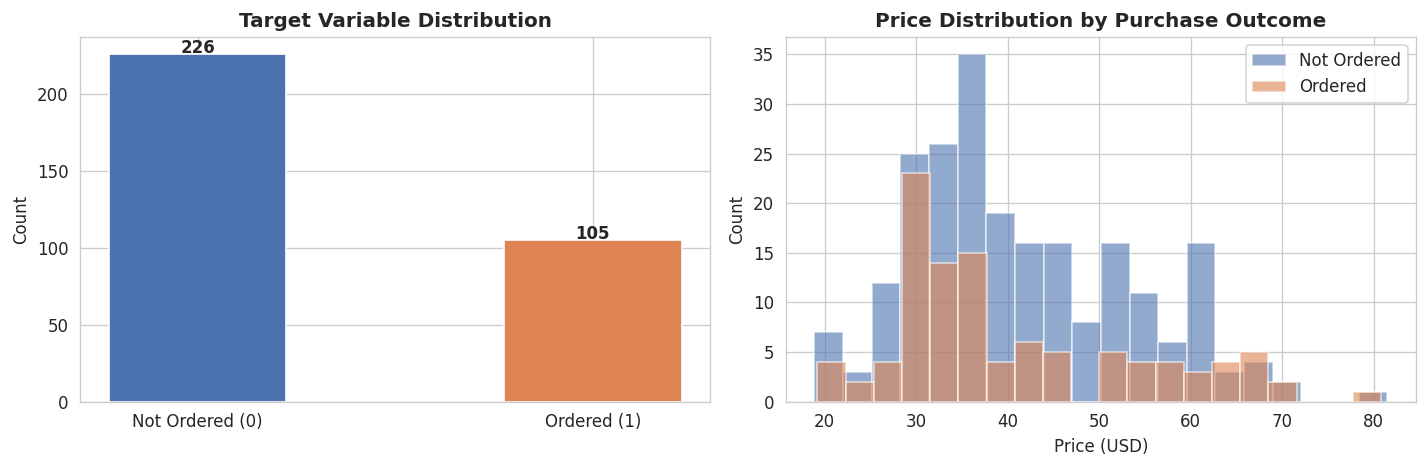

In [ ]:
# ── Target distribution ───────────────────────────────────────────────────────
target_counts = df['ordered'].value_counts()
pos_rate = df['ordered'].mean()

print(f'Target distribution:\n{target_counts}')
print(f'\nPositive rate (ordered=1): {pos_rate:.2%}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
ax = axes[0]
bars = ax.bar(['Not Ordered (0)', 'Ordered (1)'], target_counts.values,
               color=COLORS[:2], edgecolor='white', width=0.45)
for b in bars:
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 1,
            str(int(b.get_height())), ha='center', fontweight='bold')
ax.set_title('Target Variable Distribution', fontweight='bold')
ax.set_ylabel('Count')

# Price distribution by ordered
ax2 = axes[1]
for val, label, color in zip([0,1], ['Not Ordered', 'Ordered'], COLORS[:2]):
    ax2.hist(df[df['ordered']==val]['price'], bins=20, alpha=0.6, label=label, color=color)
ax2.set_title('Price Distribution by Purchase Outcome', fontweight='bold')
ax2.set_xlabel('Price (USD)')
ax2.set_ylabel('Count')
ax2.legend()

plt.tight_layout()
plt.savefig('eda_overview.png', bbox_inches='tight', dpi=130)
plt.show()

---
## Part A — Multimodal LLM Feature Engineering

We use `gemini-3-flash-preview` (with `thinking_budget=0` for deterministic, fast structured output) to extract
nine product attributes from each listing title. These structured features replace manual feature engineering
and encode domain knowledge that is hard to capture with simple regex or TF-IDF.

### Prompt Design Rationale
- **System prompt** establishes the extraction engine role, strict JSON-only output format, and an exhaustive schema with allowed values — eliminating hallucinated categories.
- **Few-shot examples** inside the system prompt align the model on edge cases (e.g. Cotton-Linen Blend vs. Cotton, Checked/Plaid colour).
- **`temperature=0`** ensures fully deterministic outputs, critical for reproducible feature construction.
- **Batch processing** (30 titles per call) reduces API latency and cost while remaining within context limits.


In [ ]:
# ── Feature schema: keys and their allowed categorical values ─────────────────
FEATURE_SCHEMA = {
    'material':        ['Cotton', 'Linen', 'Cotton-Linen Blend', 'Flannel', 'Polyester', 'Other', 'Unknown'],
    'sleeve_length':   ['Short Sleeve', 'Long Sleeve', 'Sleeveless', 'Unknown'],
    'product_type':    ['Shirt', 'Shirt Set', 'Polo', 'T-Shirt', 'Other', 'Unknown'],
    'color':           ['White', 'Black', 'Red', 'Blue', 'Navy', 'Grey', 'Khaki', 'Green',
                        'Dark Red', 'Checked/Plaid', 'Multi', 'Other', 'Unknown'],
    'size':            ['XS', 'S', 'M', 'L', 'XL', '2XL', '3XL', '4XL', '5XL', 'Unknown'],
    'style_type':      ['Casual', 'Formal', 'Business Casual', 'Leisure', 'Vintage', 'Sport', 'Other', 'Unknown'],
    'fit_type':        ['Regular', 'Slim', 'Oversized', 'Relaxed', 'Unknown'],
    'special_feature': ['Pocket', 'Washed', 'Premium', 'Textured', 'Printed', 'Embroidered', 'None', 'Unknown'],
    'target_gender':   ['Men', 'Women', 'Unisex', 'Unknown'],
}

FEATURE_SYSTEM_PROMPT = """You are a structured data extraction engine for e-commerce product titles.

Your job is to extract product features from apparel titles and return ONLY a valid JSON array — no markdown, no explanation, no code fences.

RULES:
1. Return a JSON array with exactly one object per input title, preserving input order.
2. Every object must contain the key "index" (matching the input index) plus all feature keys.
3. Every feature value MUST be chosen from its allowed list below. Never invent new values.
4. If a feature cannot be determined from the title, use "Unknown" (or "None" for special_feature).
5. The output array length must exactly match the input array length.

FEATURE SCHEMA (key: allowed values):
- material:        ["Cotton", "Linen", "Cotton-Linen Blend", "Flannel", "Polyester", "Other", "Unknown"]
- sleeve_length:   ["Short Sleeve", "Long Sleeve", "Sleeveless", "Unknown"]
- product_type:    ["Shirt", "Shirt Set", "Polo", "T-Shirt", "Other", "Unknown"]
- color:           ["White", "Black", "Red", "Blue", "Navy", "Grey", "Khaki", "Green", "Dark Red", "Checked/Plaid", "Multi", "Other", "Unknown"]
- size:            ["XS", "S", "M", "L", "XL", "2XL", "3XL", "4XL", "5XL", "Unknown"]
- style_type:      ["Casual", "Formal", "Business Casual", "Leisure", "Vintage", "Sport", "Other", "Unknown"]
- fit_type:        ["Regular", "Slim", "Oversized", "Relaxed", "Unknown"]
- special_feature: ["Pocket", "Washed", "Premium", "Textured", "Printed", "Embroidered", "None", "Unknown"]
- target_gender:   ["Men", "Women", "Unisex", "Unknown"]

EXAMPLE INPUT:
[
  {"index": 0, "title": "Men's Cotton Linen Casual Long Sleeve Shirt Khaki / XL"},
  {"index": 1, "title": "Casual Checked Flannel Shirt White/Red / L"}
]

EXAMPLE OUTPUT:
[
  {"index": 0, "material": "Cotton-Linen Blend", "sleeve_length": "Long Sleeve", "product_type": "Shirt", "color": "Khaki", "size": "XL", "style_type": "Casual", "fit_type": "Unknown", "special_feature": "None", "target_gender": "Men"},
  {"index": 1, "material": "Flannel", "sleeve_length": "Long Sleeve", "product_type": "Shirt", "color": "Checked/Plaid", "size": "L", "style_type": "Casual", "fit_type": "Unknown", "special_feature": "None", "target_gender": "Unisex"}
]"""

In [ ]:
def extract_features_batch(titles_with_index: list[dict], attempt_log: str = '') -> list[dict] | None:
    """Send a batch of {index, title} dicts to Gemini and return extracted feature dicts."""
    user_message = f'Extract features from the following product titles:\n{json.dumps(titles_with_index, indent=2)}'

    for attempt in range(3):
        try:
            response = client.models.generate_content(
                model='gemini-3-flash-preview',
                contents=user_message,
                config=types.GenerateContentConfig(
                    system_instruction=FEATURE_SYSTEM_PROMPT,
                    temperature=0.0,
                    max_output_tokens=8192,
                    thinking_config=types.ThinkingConfig(thinking_budget=0)
                )
            )
            raw = response.text.strip()
            raw = re.sub(r'^```(?:json)?\s*', '', raw)
            raw = re.sub(r'\s*```$', '', raw)
            parsed = json.loads(raw)

            input_indices  = {item['index'] for item in titles_with_index}
            output_indices = {item['index'] for item in parsed}

            if input_indices != output_indices:
                missing = input_indices - output_indices
                print(f'Alignment mismatch{attempt_log} | missing={missing} — retrying...')
                time.sleep(3)
                continue

            return parsed

        except Exception as e:
            if '429' in str(e):
                wait = 15 * (attempt + 1)
                print(f'Rate limit{attempt_log}. Sleeping {wait}s before retry {attempt+1}...')
                time.sleep(wait)
            else:
                print(f'Error{attempt_log}: {e}')
                return None
    return None


def extract_all_features(df: pd.DataFrame, title_col: str = 'title', batch_size: int = 30) -> pd.DataFrame:
    """Extract features for all rows in df, batching API calls."""
    UNKNOWN_ROW = {k: 'Unknown' for k in FEATURE_SCHEMA}
    UNKNOWN_ROW['special_feature'] = 'None'

    titles = df[title_col].tolist()
    total  = len(titles)
    all_results = {}

    batches = [
        list(range(start, min(start + batch_size, total)))
        for start in range(0, total, batch_size)
    ]
    print(f'Processing {total} titles in {len(batches)} batches of up to {batch_size}...')

    for batch_num, batch_indices in enumerate(batches, 1):
        print(f'\nBatch {batch_num}/{len(batches)} ({len(batch_indices)} titles)...')
        payload = [{'index': i, 'title': titles[i]} for i in batch_indices]
        results = extract_features_batch(payload, attempt_log=f' [batch {batch_num}]')

        if results is not None:
            for item in results:
                all_results[item['index']] = {k: item.get(k, 'Unknown') for k in FEATURE_SCHEMA}
            print(f'  ✓ Batch {batch_num} complete')
        else:
            # Row-by-row fallback
            print(f'  ↩ Batch failed — falling back to row-by-row...')
            for i in batch_indices:
                single = extract_features_batch([{'index': i, 'title': titles[i]}], attempt_log=f' [row {i}]')
                all_results[i] = {k: single[0].get(k, 'Unknown') for k in FEATURE_SCHEMA} if single else UNKNOWN_ROW.copy()
                time.sleep(2)

        if batch_num < len(batches):
            time.sleep(3)

    feat_rows = [all_results[i] for i in range(total)]
    feat_df   = pd.DataFrame(feat_rows)
    return pd.concat([df.reset_index(drop=True), feat_df], axis=1)


print('Feature extraction functions defined.')

Feature extraction functions defined.


In [ ]:
# ── Run feature extraction ────────────────────────────────────────────────────
# This call hits the Gemini API. Results are saved to CSV so it only needs to run once.
df_features = extract_all_features(df, title_col='title', batch_size=30)

df_features.to_csv('dataset_with_features.csv', index=False)
print('\n Saved to dataset_with_features.csv')
print(df_features[list(FEATURE_SCHEMA.keys())].head())


Processing 331 titles in 12 batches of up to 30...

Batch 1/12 (30 titles)...
  ✓ Batch 1 complete

Batch 2/12 (30 titles)...
  ✓ Batch 2 complete

Batch 3/12 (30 titles)...
  ✓ Batch 3 complete

Batch 4/12 (30 titles)...
  ✓ Batch 4 complete

Batch 5/12 (30 titles)...
  ✓ Batch 5 complete

Batch 6/12 (30 titles)...
  ✓ Batch 6 complete

Batch 7/12 (30 titles)...
  ✓ Batch 7 complete

Batch 8/12 (30 titles)...
  ✓ Batch 8 complete

Batch 9/12 (30 titles)...
  ✓ Batch 9 complete

Batch 10/12 (30 titles)...
  ✓ Batch 10 complete

Batch 11/12 (30 titles)...
  ✓ Batch 11 complete

Batch 12/12 (1 titles)...
  ✓ Batch 12 complete

 Saved to dataset_with_features.csv
             material sleeve_length product_type          color size  \
0  Cotton-Linen Blend   Long Sleeve        Shirt           Blue  4XL   
1             Flannel   Long Sleeve        Shirt  Checked/Plaid    L   
2               Linen   Long Sleeve        Shirt          Khaki  5XL   
3             Unknown       Unknown    Shir

In [ ]:
# ── Load pre-extracted features (skip API call if CSV already exists) ─────────
df_features = pd.read_csv('dataset_with_features.csv')
print(f'Loaded: {df_features.shape}')
df_features[list(FEATURE_SCHEMA.keys())].head()

Loaded: (331, 14)


,material,sleeve_length,product_type,color,size,style_type,fit_type,special_feature,target_gender
0,Cotton-Linen Blend,Long Sleeve,Shirt,Blue,4XL,Casual,Unknown,NaN,Men
1,Flannel,Long Sleeve,Shirt,Checked/Plaid,L,Casual,Unknown,NaN,Unknown
2,Linen,Long Sleeve,Shirt,Khaki,5XL,Unknown,Unknown,NaN,Men
3,Unknown,Unknown,Shirt Set,Dark Red,L,Leisure,Unknown,Textured,Unknown
4,Cotton,Unknown,Shirt,Grey,L,Unknown,Unknown,Pocket,Men


---
## Part B — Embedding-Based Feature Engineering

As a second representation, we use Gemini's `gemini-embedding-001` model to embed each product title
into a 3072-dimensional semantic vector. PCA is then applied (fit on training data only to prevent leakage)
to reduce dimensionality to 20 components while retaining the majority of variance.

This approach captures subtle semantic similarity between products without requiring explicit feature definitions,
making it complementary to the structured feature extraction in Part A.


In [ ]:
EMBEDDING_MODEL = 'gemini-embedding-001'
EMBED_BATCH_SIZE = 90        # stay safely under 100/min rate limit
EMBED_SLEEP      = 65        # seconds to sleep between batches


async def get_embedding_async(text: str) -> list[float] | None:
    """Async wrapper around Gemini embed_content."""
    try:
        text = str(text)[:2000].strip() or ' '
        loop = asyncio.get_event_loop()
        result = await loop.run_in_executor(
            None,
            lambda: client.models.embed_content(model=EMBEDDING_MODEL, contents=text)
        )
        return result.embeddings[0].values
    except Exception as e:
        print(f'Embedding error: {e}')
        return None


async def embed_all_titles_async(titles: list[str]) -> list[list[float] | None]:
    """Embed all titles in rate-limited batches."""
    all_embeddings = []
    total_batches  = (len(titles) + EMBED_BATCH_SIZE - 1) // EMBED_BATCH_SIZE

    for i in range(0, len(titles), EMBED_BATCH_SIZE):
        batch     = titles[i : i + EMBED_BATCH_SIZE]
        batch_num = (i // EMBED_BATCH_SIZE) + 1
        print(f'Embedding batch {batch_num}/{total_batches} ({len(batch)} titles)...')

        results = await asyncio.gather(*[get_embedding_async(t) for t in batch])
        all_embeddings.extend(results)
        print(f'  ✅ Batch {batch_num} done — {len(all_embeddings)}/{len(titles)} total')

        if i + EMBED_BATCH_SIZE < len(titles):
            print(f'  ⏳ Waiting {EMBED_SLEEP}s for rate limit reset...')
            time.sleep(EMBED_SLEEP)

    return all_embeddings


print('Embedding functions defined.')

Embedding functions defined.


In [ ]:
# ── Run embedding — this is the slow step (~2–3 min for 331 titles) ───────────
# Embeddings are saved to JSON so this only needs to run once.
titles_list  = df['title'].tolist()
all_embeddings = await embed_all_titles_async(titles_list)   # Colab supports top-level await

with open('title_embeddings.json', 'w') as f:
    json.dump([list(e) if e else None for e in all_embeddings], f)

print(f'\n Saved {len(all_embeddings)} embeddings to title_embeddings.json')
print(f'Embedding dimension: {len(all_embeddings[0])}')

Embedding batch 1/4 (90 titles)...
  ✅ Batch 1 done — 90/331 total
  ⏳ Waiting 65s for rate limit reset...
Embedding batch 2/4 (90 titles)...
  ✅ Batch 2 done — 180/331 total
  ⏳ Waiting 65s for rate limit reset...
Embedding batch 3/4 (90 titles)...
  ✅ Batch 3 done — 270/331 total
  ⏳ Waiting 65s for rate limit reset...
Embedding batch 4/4 (61 titles)...
  ✅ Batch 4 done — 331/331 total

 Saved 331 embeddings to title_embeddings.json
Embedding dimension: 3072


In [ ]:
# ── Load embeddings + apply PCA ───────────────────────────────────────────────
with open('title_embeddings.json') as f:
    loaded_embeddings = json.load(f)

df_emb = df[['title', 'price', 'ordered']].copy().reset_index(drop=True)
df_emb['title_embedding'] = loaded_embeddings

# ── Train/test split (stratified) ────────────────────────────────────────────
train_idx, test_idx = train_test_split(
    df_emb.index, test_size=0.2, random_state=42, stratify=df_emb['ordered']
)

# ── PCA — fit only on training data to prevent leakage ───────────────────────
embeddings_matrix = np.array(df_emb['title_embedding'].tolist())
N_COMPONENTS = 20

pca = PCA(n_components=N_COMPONENTS, random_state=42)
pca.fit(embeddings_matrix[train_idx])
pca_embeddings = pca.transform(embeddings_matrix)

pca_df = pd.DataFrame(
    pca_embeddings,
    index=df_emb.index,
    columns=[f'pca_emb_{i}' for i in range(N_COMPONENTS)]
)

explained = pca.explained_variance_ratio_.sum() * 100
print(f'Original dim {embeddings_matrix.shape[1]} → Reduced to {N_COMPONENTS}')
print(f'Variance explained by {N_COMPONENTS} components: {explained:.1f}%')

# ── Build feature matrices for embedding-based model ─────────────────────────
X_emb = pd.concat([df_emb[['price']], pca_df], axis=1)
y_emb = df_emb['ordered']

X_train_emb, X_test_emb = X_emb.loc[train_idx], X_emb.loc[test_idx]
y_train_emb, y_test_emb = y_emb.loc[train_idx], y_emb.loc[test_idx]

print(f'Train: {X_train_emb.shape} | Test: {X_test_emb.shape}')

Original dim 3072 → Reduced to 20
Variance explained by 20 components: 67.0%
Train: (264, 21) | Test: (67, 21)


In [ ]:
# ── Baseline: price-only XGBoost ─────────────────────────────────────────────
model_base = XGBClassifier(
    objective='binary:logistic', n_estimators=100, max_depth=3,
    reg_lambda=1, reg_alpha=0.1, random_state=42, eval_metric='logloss'
)
model_base.fit(X_train_emb[['price']], y_train_emb)
prob_base = model_base.predict_proba(X_test_emb[['price']])[:, 1]

print(f'Baseline XGBoost (price only)  AUC: {roc_auc_score(y_test_emb, prob_base):.4f}')

# ── Embedding XGBoost ─────────────────────────────────────────────────────────
model_emb = XGBClassifier(
    objective='binary:logistic', n_estimators=100, max_depth=3,
    reg_lambda=1, reg_alpha=0.1, random_state=42, eval_metric='auc'
)
model_emb.fit(X_train_emb, y_train_emb)
prob_emb = model_emb.predict_proba(X_test_emb)[:, 1]

print(f'XGBoost (price + PCA-20 embed)  AUC: {roc_auc_score(y_test_emb, prob_emb):.4f}')

Baseline XGBoost (price only)  AUC: 0.5813
XGBoost (price + PCA-20 embed)  AUC: 0.6522


In [ ]:
# ── Tuned XGBoost on embeddings (RandomizedSearchCV) ─────────────────────────
scale_pos_weight_emb = (y_train_emb == 0).sum() / (y_train_emb == 1).sum()

xgb_emb_param_grid = {
    'n_estimators':     [100, 200, 400],
    'max_depth':        [2, 3, 4, 5],
    'learning_rate':    [0.01, 0.05, 0.1, 0.2],
    'subsample':        [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'min_child_weight': [1, 3, 5],
}

cv_emb = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

xgb_emb_search = RandomizedSearchCV(
    XGBClassifier(
        scale_pos_weight=scale_pos_weight_emb,
        eval_metric='logloss',
        random_state=42,
    ),
    xgb_emb_param_grid,
    n_iter=40, cv=cv_emb, scoring='roc_auc',
    random_state=42, n_jobs=-1, refit=True
)
xgb_emb_search.fit(X_train_emb, y_train_emb)

print(f'Tuned XGB + Embeddings  CV AUC : {xgb_emb_search.best_score_:.4f}')
print(f'Best params : {xgb_emb_search.best_params_}')

Tuned XGB + Embeddings  CV AUC : 0.5463
Best params : {'subsample': 0.6, 'n_estimators': 400, 'min_child_weight': 5, 'max_depth': 2, 'learning_rate': 0.2, 'colsample_bytree': 0.8}


In [ ]:
# ── Evaluate tuned embedding model ────────────────────────────────────────────
best_xgb_emb = xgb_emb_search.best_estimator_
prob_emb      = best_xgb_emb.predict_proba(X_test_emb)[:, 1]   # overwrites untuned prob_emb

print(f'Tuned XGB + Embeddings  Test AUC : {roc_auc_score(y_test_emb, prob_emb):.4f}')
print(f'Tuned XGB + Embeddings  PR-AUC   : {average_precision_score(y_test_emb, prob_emb):.4f}')

Tuned XGB + Embeddings  Test AUC : 0.6667
Tuned XGB + Embeddings  PR-AUC   : 0.4638


In [ ]:
# ── Tuned Random Forest on embeddings ────────────────────────────────────────
rf_emb_param_grid = {
    'n_estimators':     [200, 400, 600],
    'max_depth':        [None, 5, 10, 15],
    'min_samples_leaf': [1, 2, 4],
    'max_features':     ['sqrt', 'log2', 0.5],
    'class_weight':     ['balanced', 'balanced_subsample'],
}

rf_emb_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    rf_emb_param_grid,
    n_iter=40, cv=cv_emb, scoring='roc_auc',
    random_state=42, n_jobs=-1, refit=True
)
rf_emb_search.fit(X_train_emb, y_train_emb)

print(f'Tuned RF + Embeddings  CV AUC : {rf_emb_search.best_score_:.4f}')
print(f'Best params : {rf_emb_search.best_params_}')

Tuned RF + Embeddings  CV AUC : 0.5066
Best params : {'n_estimators': 200, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 5, 'class_weight': 'balanced_subsample'}


In [ ]:
# ── Evaluate tuned RF on embeddings ──────────────────────────────────────────
best_rf_emb  = rf_emb_search.best_estimator_
prob_rf_emb  = best_rf_emb.predict_proba(X_test_emb)[:, 1]

print(f'Tuned RF + Embeddings  Test AUC : {roc_auc_score(y_test_emb, prob_rf_emb):.4f}')
print(f'Tuned RF + Embeddings  PR-AUC   : {average_precision_score(y_test_emb, prob_rf_emb):.4f}')

Tuned RF + Embeddings  Test AUC : 0.6998
Tuned RF + Embeddings  PR-AUC   : 0.5191


---
## Part C — Machine Learning Benchmarks (LLM Features → ML)

We use the structured features extracted in Part A as inputs to three ML classifiers:
- **Logistic Regression** (with L1/L2 regularisation via `liblinear`/`saga`)
- **Random Forest**
- **XGBoost**

All models are tuned with `RandomizedSearchCV` using 5-fold stratified cross-validation, optimising **ROC-AUC** — the metric that best reflects ranking quality for the product selection task.

Additional hand-crafted features derived from the title text (keyword flags, price tiers, word count) are also included alongside the LLM-extracted categorical features.


In [ ]:
# ── Load LLM-extracted features ───────────────────────────────────────────────
df_ml = pd.read_csv('dataset_with_features.csv')
print(f'Shape: {df_ml.shape}')
df_ml[list(FEATURE_SCHEMA.keys())].head()

Shape: (331, 14)


,material,sleeve_length,product_type,color,size,style_type,fit_type,special_feature,target_gender
0,Cotton-Linen Blend,Long Sleeve,Shirt,Blue,4XL,Casual,Unknown,NaN,Men
1,Flannel,Long Sleeve,Shirt,Checked/Plaid,L,Casual,Unknown,NaN,Unknown
2,Linen,Long Sleeve,Shirt,Khaki,5XL,Unknown,Unknown,NaN,Men
3,Unknown,Unknown,Shirt Set,Dark Red,L,Leisure,Unknown,Textured,Unknown
4,Cotton,Unknown,Shirt,Grey,L,Unknown,Unknown,Pocket,Men


In [ ]:
# ── Feature engineering ───────────────────────────────────────────────────────
feat = df_ml.drop(columns=['title', 'image', 'image_path', 'ordered']).copy()
feat['special_feature'] = feat['special_feature'].fillna('None')

# Numeric / text-derived features
feat['price_log']         = np.log1p(feat['price'])
feat['price_tier']        = pd.cut(feat['price'], bins=[0, 20, 35, 50, 200],
                                    labels=[0,1,2,3]).astype(int)
feat['title_word_count']  = df_ml['title'].str.split().str.len()
feat['title_has_premium'] = df_ml['title'].str.lower().str.contains('premium|luxury').astype(int)
feat['title_has_casual']  = df_ml['title'].str.lower().str.contains('casual|leisure').astype(int)
feat['title_has_vintage'] = df_ml['title'].str.lower().str.contains('vintage|classic').astype(int)
feat['title_has_cotton']  = df_ml['title'].str.lower().str.contains('cotton|linen|flannel').astype(int)

# One-hot encoding for nominal categoricals
OHE_COLS = ['material', 'sleeve_length', 'product_type', 'color',
             'style_type', 'fit_type', 'special_feature', 'target_gender']
feat = pd.get_dummies(feat, columns=OHE_COLS, drop_first=False, dtype=int)

# Ordinal encoding for size (natural order exists)
size_order = {'S':1,'M':2,'L':3,'XL':4,'2XL':5,'3XL':6,'4XL':7,'5XL':8,'Unknown':0}
feat['size_ordinal'] = df_ml['size'].map(size_order).fillna(0).astype(int)
feat.drop(columns=['size'], inplace=True, errors='ignore')

X_ml = feat.astype(float)
y_ml = df_ml['ordered']

print(f'Total features after encoding: {X_ml.shape[1]}')
print(list(X_ml.columns))

Total features after encoding: 56
['price', 'price_log', 'price_tier', 'title_word_count', 'title_has_premium', 'title_has_casual', 'title_has_vintage', 'title_has_cotton', 'material_Cotton', 'material_Cotton-Linen Blend', 'material_Flannel', 'material_Linen', 'material_Other', 'material_Unknown', 'sleeve_length_Long Sleeve', 'sleeve_length_Short Sleeve', 'sleeve_length_Unknown', 'product_type_Other', 'product_type_Polo', 'product_type_Shirt', 'product_type_Shirt Set', 'product_type_T-Shirt', 'color_Black', 'color_Blue', 'color_Checked/Plaid', 'color_Dark Red', 'color_Green', 'color_Grey', 'color_Khaki', 'color_Multi', 'color_Navy', 'color_Other', 'color_Red', 'color_White', 'style_type_Business Casual', 'style_type_Casual', 'style_type_Formal', 'style_type_Leisure', 'style_type_Other', 'style_type_Sport', 'style_type_Unknown', 'style_type_Vintage', 'fit_type_Relaxed', 'fit_type_Slim', 'fit_type_Unknown', 'special_feature_Embroidered', 'special_feature_None', 'special_feature_Pocket', 

In [ ]:
# ── Train/test split ──────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X_ml, y_ml, test_size=0.2, random_state=42, stratify=y_ml
)

print(f'Train: {X_train.shape[0]} rows  |  Test: {X_test.shape[0]} rows')
print(f'Train positive rate: {y_train.mean():.2%}')
print(f'Test  positive rate: {y_test.mean():.2%}')

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

Train: 264 rows  |  Test: 67 rows
Train positive rate: 31.82%
Test  positive rate: 31.34%


In [ ]:
# ── Logistic Regression ───────────────────────────────────────────────────────
lr_param_grid = {
    'm__C':            [0.001, 0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0],
    'm__penalty':      ['l1', 'l2'],
    'm__solver':       ['liblinear', 'saga'],
    'm__class_weight': ['balanced']
}
lr_pipe = Pipeline([('sc', StandardScaler()), ('m', LogisticRegression(max_iter=3000, random_state=42))])
lr_search = RandomizedSearchCV(lr_pipe, lr_param_grid, n_iter=30, cv=cv,
                                scoring='roc_auc', random_state=42, n_jobs=-1)
lr_search.fit(X_train, y_train)
print(f'LR  best CV AUC: {lr_search.best_score_:.4f}  |  params: {lr_search.best_params_}')

LR  best CV AUC: 0.5000  |  params: {'m__solver': 'liblinear', 'm__penalty': 'l1', 'm__class_weight': 'balanced', 'm__C': 0.05}


In [ ]:
# ── Random Forest ─────────────────────────────────────────────────────────────
rf_param_grid = {
    'n_estimators':     [200, 400, 600],
    'max_depth':        [None, 5, 10, 15],
    'min_samples_leaf': [1, 2, 4],
    'max_features':     ['sqrt', 'log2', 0.5],
    'class_weight':     ['balanced', 'balanced_subsample']
}
rf_search = RandomizedSearchCV(RandomForestClassifier(random_state=42, n_jobs=-1),
                                rf_param_grid, n_iter=40, cv=cv,
                                scoring='roc_auc', random_state=42, n_jobs=-1)
rf_search.fit(X_train, y_train)
print(f'RF  best CV AUC: {rf_search.best_score_:.4f}  |  params: {rf_search.best_params_}')

RF  best CV AUC: 0.4488  |  params: {'n_estimators': 400, 'min_samples_leaf': 4, 'max_features': 0.5, 'max_depth': 10, 'class_weight': 'balanced'}


In [ ]:
# ── XGBoost ───────────────────────────────────────────────────────────────────
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f'scale_pos_weight: {scale_pos_weight:.2f}')

xgb_param_grid = {
    'n_estimators':     [100, 200, 400],
    'max_depth':        [2, 3, 4, 5],
    'learning_rate':    [0.01, 0.05, 0.1, 0.2],
    'subsample':        [0.6, 0.7, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'min_child_weight': [1, 3, 5]
}
xgb_search = RandomizedSearchCV(
    XGBClassifier(scale_pos_weight=scale_pos_weight, eval_metric='logloss', random_state=42),
    xgb_param_grid, n_iter=40, cv=cv, scoring='roc_auc', random_state=42, n_jobs=-1
)
xgb_search.fit(X_train, y_train)
print(f'XGB best CV AUC: {xgb_search.best_score_:.4f}  |  params: {xgb_search.best_params_}')

scale_pos_weight: 2.14
XGB best CV AUC: 0.4674  |  params: {'subsample': 1.0, 'n_estimators': 400, 'min_child_weight': 3, 'max_depth': 2, 'learning_rate': 0.01, 'colsample_bytree': 0.8}


In [ ]:
# ── Evaluate ML models ────────────────────────────────────────────────────────
best_lr  = lr_search.best_estimator_
best_rf  = rf_search.best_estimator_
best_xgb = xgb_search.best_estimator_

prob_lr       = best_lr.predict_proba(X_test)[:, 1]
prob_rf       = best_rf.predict_proba(X_test)[:, 1]
prob_xgb_ml   = best_xgb.predict_proba(X_test)[:, 1]
prob_ensemble = np.mean([prob_lr, prob_rf, prob_xgb_ml], axis=0)

ml_model_probs = [
    ('Logistic Regression', prob_lr,       lr_search.best_score_),
    ('Random Forest',       prob_rf,       rf_search.best_score_),
    ('XGBoost (LLM feats)', prob_xgb_ml,   xgb_search.best_score_),
    ('Ensemble (Avg)',      prob_ensemble, None),
]

print(f'{"Model":<25} {"CV AUC":>10}  {"Test AUC":>10}  {"PR-AUC":>10}')
print('-' * 62)
for name, prob, cv_auc in ml_model_probs:
    tauc  = roc_auc_score(y_test, prob)
    prauc = average_precision_score(y_test, prob)
    cv_str = f'{cv_auc:.4f}' if cv_auc else '  —   '
    print(f'{name:<25} {cv_str:>10}  {tauc:>10.4f}  {prauc:>10.4f}')

Model                         CV AUC    Test AUC      PR-AUC
--------------------------------------------------------------
Logistic Regression           0.5000      0.5000      0.3134
Random Forest                 0.4488      0.7288      0.5941
XGBoost (LLM feats)           0.4674      0.6791      0.4928
Ensemble (Avg)                  —         0.7091      0.5807


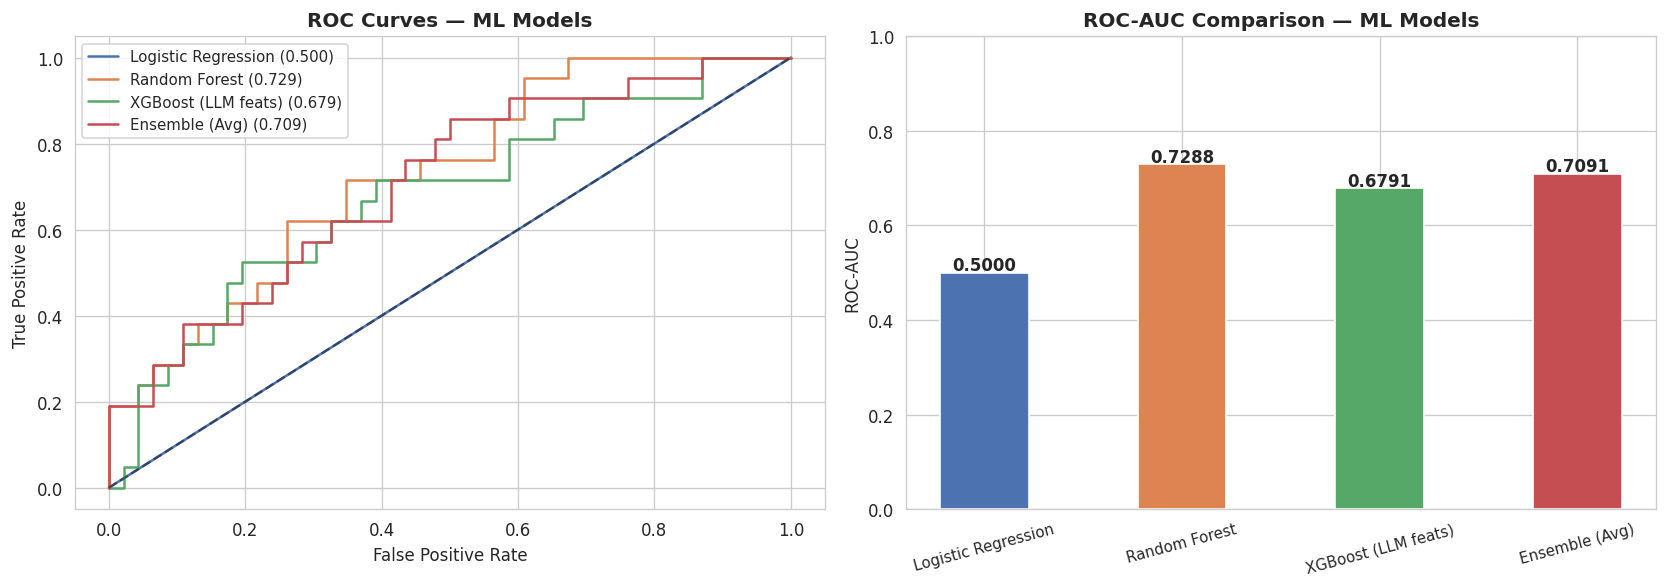

In [ ]:
# ── ROC Curves ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for (name, prob, _), color in zip(ml_model_probs, COLORS):
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc_val = roc_auc_score(y_test, prob)
    axes[0].plot(fpr, tpr, label=f'{name} ({auc_val:.3f})', color=color)
axes[0].plot([0,1],[0,1],'k--', alpha=0.4)
axes[0].set_title('ROC Curves — ML Models', fontweight='bold')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(fontsize=9)

# AUC bar chart
auc_vals = {name: roc_auc_score(y_test, prob) for name, prob, _ in ml_model_probs}
bars = axes[1].bar(auc_vals.keys(), auc_vals.values(), color=COLORS, edgecolor='white', width=0.45)
for b in bars:
    axes[1].text(b.get_x() + b.get_width()/2, b.get_height() + 0.005,
                  f'{b.get_height():.4f}', ha='center', fontsize=10, fontweight='bold')
axes[1].set_ylim(0, 1.0)
axes[1].set_ylabel('ROC-AUC')
axes[1].set_title('ROC-AUC Comparison — ML Models', fontweight='bold')
plt.xticks(rotation=15, fontsize=9)
plt.tight_layout()
plt.savefig('ml_auc_comparison.png', bbox_inches='tight', dpi=130)
plt.show()

In [ ]:
# ── Product ranking table: top-K by Price × P(purchase) ──────────────────────
prob_table = pd.DataFrame({
    'title':             df_ml.loc[X_test.index, 'title'].values,
    'price':             df_ml.loc[X_test.index, 'price'].values,
    'actual_ordered':    y_test.values,
    'prob_LR':           np.round(prob_lr, 4),
    'prob_RF':           np.round(prob_rf, 4),
    'prob_XGB':          np.round(prob_xgb_ml, 4),
    'ensemble_prob':     np.round(prob_ensemble, 4),
}, index=X_test.index)

# Expected revenue score: Price × P(purchase)
prob_table['expected_revenue'] = prob_table['price'] * prob_table['ensemble_prob']
prob_table_sorted = prob_table.sort_values('expected_revenue', ascending=False)
prob_table_sorted.to_csv('ml_product_rankings.csv', index=True)

print('Top 10 products ranked by expected revenue (Price × P(purchase)):')
prob_table_sorted[['title','price','ensemble_prob','expected_revenue','actual_ordered']].head(10)

Top 10 products ranked by expected revenue (Price × P(purchase)):


,title,price,ensemble_prob,expected_revenue,actual_ordered
158,Men's Cotton printed shirt Blue / L,71.49,0.5648,40.377552,0
55,Effortless Comfort Textured Shirt Set Khaki / L,70.41,0.5421,38.169261,0
62,Essential Muscle Fit Dress Shirt White / L,66.74,0.5577,37.220898,1
80,Effortless Comfort Textured Shirt Set Navy Blu...,68.53,0.5407,37.054171,0
168,Men's Vintage Premium Washed Shirt Army Green / L,66.11,0.5399,35.692789,1
119,Essential Muscle Fit Dress Shirt Navy blue / L,64.08,0.4746,30.412368,1
94,Leisure Textured Shirt Set Red / XXXL,41.81,0.6051,25.299231,1
25,Essential Muscle Fit Dress Shirt Burgundy / XL,63.24,0.3922,24.802728,1
330,Casual Cotton Linen Shirt Set White / XXXL,56.58,0.4309,24.380322,0
3,Leisure Textured Shirt Set Dark Red / L,45.10,0.5359,24.169090,0


---
## Part D — Pure LLM Prediction (AI Buyer Agent)

In this section, the multimodal LLM **directly predicts purchase probability** without using a downstream ML classifier.
The model simulates the decision-making process of a human buyer evaluating products based on:
- Product title (text)
- Product image URL (visual, multimodal)
- Listed price

We implement three progressively sophisticated prompting strategies:

| Strategy | Description |
|---|---|
| **One-Shot** | Direct question with role context; no examples provided |
| **Few-Shot** | 6 labelled examples (3 ordered, 3 not ordered) prime the model's judgment |
| **Chain-of-Thought** | Model explicitly reasons step-by-step before outputting a score |

All strategies output a **purchase probability in [0, 1]** plus a brief justification,
enabling comparison with ML baselines on the same test set.


### D.1 — Helper Utilities

A shared parsing function extracts the numeric probability from LLM responses,
and a shared call function handles rate-limit retries with exponential back-off.


In [ ]:
# ── Shared helpers ────────────────────────────────────────────────────────────
import requests

def get_image_bytes(url: str) -> bytes | None:
    try:
        r = requests.get(url, timeout=10)
        r.raise_for_status()
        return r.content
    except Exception as e:
        print(f'  ⚠ Image fetch failed: {e}')
        return None


def parse_prob_from_response(text: str) -> float:
    for pattern in [
        r'["\']?(?:purchase_probability|probability|prob|score)["\']?\s*[:=]\s*([0-9]*\.?[0-9]+)',
        r'(?:probability|score|prob(?:ability)?)\s*(?:of|is|:)?\s*([0-9]*\.?[0-9]+)',
        r'([0-1]\.[0-9]+)',
        r'\b(0|1)\b',
    ]:
        matches = re.findall(pattern, text, re.IGNORECASE)
        for m in matches:
            try:
                val = float(m)
                if 0.0 <= val <= 1.0:
                    return round(val, 4)
            except ValueError:
                continue
    return 0.5


def build_batch_contents(batch_rows: pd.DataFrame, user_text_fn) -> list:
    """
    Build a multimodal contents list for a batch of products.
    user_text_fn(pos, row) -> str: formats the text description for each product.
    Images are fetched and interleaved with text.
    """
    contents = []
    for pos, (idx, row) in enumerate(batch_rows.iterrows(), 1):
        contents.append(f'Product {pos}:')
        img_bytes = get_image_bytes(row['image'])
        if img_bytes:
            contents.append(types.Part.from_bytes(data=img_bytes, mime_type='image/jpeg'))
        contents.append(user_text_fn(pos, row))
    return contents


def parse_batch_response(raw: str, batch_size: int) -> dict:
    """
    Parse a JSON array response from a batched LLM call.
    Returns dict of {0-based-pos: (prob, justification)}.
    Falls back to empty dict on parse failure.
    """
    try:
        clean  = re.sub(r'^```(?:json)?\s*', '', raw)
        clean  = re.sub(r'\s*```$', '', clean).strip()
        parsed = json.loads(clean)
        result = {}
        for item in parsed:
            pos  = int(item.get('product_index', 0)) - 1
            prob = float(item.get('purchase_probability', 0.5))
            prob = round(max(0.0, min(1.0, prob)), 4)
            just = item.get('justification', '')
            if 0 <= pos < batch_size:
                result[pos] = (prob, just)
        return result
    except Exception as e:
        print(f'  ⚠ Parse error: {e}')
        print(f'  Raw: {raw[:300]}')
        return {}


def call_llm_batch(
    contents: list,
    system_prompt: str,
    batch_num: int,
    model: str = 'gemini-2.0-flash',
    temperature: float = 0.1,
    max_output_tokens: int = 2048,
) -> str | None:
    """
    Send a batched contents list to the Gemini API with retry logic.
    Returns raw response text or None on failure.
    """
    for attempt in range(4):
        try:
            response = client.models.generate_content(
                model=model,
                contents=contents,
                config=types.GenerateContentConfig(
                    system_instruction=system_prompt,
                    temperature=temperature,
                    max_output_tokens=max_output_tokens,
                )
            )
            return response.text.strip()
        except Exception as e:
            if '429' in str(e):
                wait = 30 * (attempt + 1)
                print(f'  ⚡ Rate limit [batch {batch_num}]. Sleeping {wait}s...')
                time.sleep(wait)
            else:
                print(f'  ✗ API error [batch {batch_num}]: {e}')
                return None
    return None


def run_batched_strategy(
    test_df: pd.DataFrame,
    system_prompt: str,
    strategy_name: str,
    user_text_fn,            # callable(pos, row) -> str
    closing_instruction: str,
    model: str = 'gemini-3-flash-preview',
    batch_size: int = 10,
    sleep_between: float = 10.0,
    temperature: float = 0.1,
    max_output_tokens: int = 8192,
) -> pd.DataFrame:
    """
    General-purpose batched LLM strategy runner shared by all three strategies.
    Each batch sends batch_size products in one API call and parses a JSON array response.
    """
    indices = list(test_df.index)
    batches = [indices[i:i+batch_size] for i in range(0, len(indices), batch_size)]
    all_results = []

    print(f'Running [{strategy_name}] on {len(indices)} products in {len(batches)} batches...')

    for batch_num, batch_idx in enumerate(batches, 1):
        batch_rows = test_df.loc[batch_idx]

        # Build multimodal contents
        contents = build_batch_contents(batch_rows, user_text_fn)
        contents.append(closing_instruction.format(n=len(batch_idx)))

        # Call API
        raw = call_llm_batch(
            contents          = contents,
            system_prompt     = system_prompt,
            batch_num         = batch_num,
            model             = model,
            temperature       = temperature,
            max_output_tokens = max_output_tokens,
        )

        # Parse response
        batch_probs = parse_batch_response(raw, len(batch_idx)) if raw else {}

        # Store results
        for pos, (idx, row) in enumerate(batch_rows.iterrows()):
            prob, just = batch_probs.get(pos, (0.5, 'parse_failed'))
            all_results.append({
                'index':          idx,
                'title':          row['title'],
                'price':          row['price'],
                'actual_ordered': row['ordered'],
                'raw_response':   just,
                'llm_prob':       prob,
            })

        print(f'  ✓ Batch {batch_num}/{len(batches)} complete')
        if batch_num < len(batches):
            time.sleep(sleep_between)

    return pd.DataFrame(all_results).set_index('index')


print('✅ Shared helper functions defined.')

✅ Shared helper functions defined.


### D.2 — Build LLM Test Set

We use the **same 20% test split** (66 products) used by all ML models to ensure fair comparison.
For LLM evaluation, we work directly from the original `df` with `title`, `image`, `price`, and `ordered` columns.
The `image` column contains product photo URLs which Gemini can fetch and interpret for multimodal reasoning.


In [ ]:
# ── Build LLM test set from the same stratified split ─────────────────────────
# We use the same X_test.index (66 rows) from Section C for fair comparison
df_llm_test = df.loc[X_test.index, ['title', 'image', 'price', 'ordered']].copy()
print(f'LLM test set: {df_llm_test.shape[0]} products')
print(f'Positive rate in test set: {df_llm_test["ordered"].mean():.2%}')
df_llm_test.head(3)

LLM test set: 67 products
Positive rate in test set: 31.34%


,title,image,price,ordered
0,Men's Cotton Linen Casual Long Sleeve Shirt Li...,http://t3.gstatic.com/shopping?q=tbn:ANd9GcSwp...,35.44,1
219,Men's Summer Solid Color Comfortable V-neck Sh...,http://t3.gstatic.com/shopping?q=tbn:ANd9GcQ1q...,18.86,0
217,Men's Cotton Knit Striped Polo Shirt Khaki / 4XL,http://t0.gstatic.com/shopping?q=tbn:ANd9GcTWc...,36.06,1


### D.3 — Strategy 1: One-Shot Prediction

The model is given only the product information and its role context — no labelled examples.
This tests the LLM's inherent e-commerce domain knowledge and multimodal visual reasoning.

**Prompt design choices:**
- Adopts the persona of an experienced e-commerce buyer analyst to activate domain-relevant priors
- Asks for structured JSON output to enable reliable probability parsing
- Includes the image URL so the model can visually assess product appeal
- Instructs the model to consider price sensitivity and market positioning


In [ ]:
# ── Zero-Shot ─────────────────────────────────────────────────────────────────
ZERO_SHOT_SYSTEM = """
You are an expert e-commerce buyer analyst with 10 years of experience in apparel retail.
You will be given a batch of products to evaluate simultaneously. Each product is described
by its image, title, and price.

For each product, assess whether it is likely to receive a purchase order when shown
to customers under a standard advertising budget on an e-commerce platform.

Evaluate each product based on:
- Product image (visual appeal, photography quality, presentation)
- Product title (name, material, style, size, colour)
- Price point (competitiveness and perceived value)

Return a JSON array with one object per product in the exact same order as the input.
Each object must contain exactly these fields:
  - product_index: the number shown before the product (1, 2, 3, ...)
  - purchase_probability: float between 0 and 1
  - justification: one sentence rationale

Output ONLY the JSON array. No markdown, no explanation, no code fences.
"""

def zero_shot_text_fn(pos: int, row) -> str:
    return (
        f'Title: {row["title"]}\n'
        f'Price: ${row["price"]:.2f}\n'
    )

ZERO_SHOT_CLOSING = (
    'Now return a JSON array with {n} objects (one per product, in order). '
    'Fields: product_index, purchase_probability, justification. '
    'Output ONLY the JSON array.'
)

print('Zero-shot prompt defined.')

Zero-shot prompt defined.


In [ ]:
# ── Run Zero-Shot ─────────────────────────────────────────────────────────────
df_zeroshot = run_batched_strategy(
    test_df             = df_llm_test,
    system_prompt       = ZERO_SHOT_SYSTEM,
    strategy_name       = 'Zero-Shot',
    user_text_fn        = zero_shot_text_fn,
    closing_instruction = ZERO_SHOT_CLOSING,
    batch_size          = 10,
    sleep_between       = 10.0,
)

auc_zs = roc_auc_score(df_zeroshot['actual_ordered'], df_zeroshot['llm_prob'])
print(f'\nZero-Shot ROC-AUC: {auc_zs:.4f}')
df_zeroshot.to_csv('predictions_zero_shot.csv')
df_zeroshot[['title','price','actual_ordered','llm_prob','raw_response']].head(5)

Running [Zero-Shot] on 67 products in 7 batches...
  ✓ Batch 1/7 complete
  ✓ Batch 2/7 complete
  ✓ Batch 3/7 complete
  ✓ Batch 4/7 complete
  ✗ API error [batch 5]: 503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.', 'status': 'UNAVAILABLE'}}
  ✓ Batch 5/7 complete
  ✓ Batch 6/7 complete
  ✓ Batch 7/7 complete

Zero-Shot ROC-AUC: 0.4752


,title,price,actual_ordered,llm_prob,raw_response
index,,,,,
0,Men's Cotton Linen Casual Long Sleeve Shirt Li...,35.44,1,0.75,The light blue linen-blend shirt is a timeless...
219,Men's Summer Solid Color Comfortable V-neck Sh...,18.86,0,0.65,While the price is highly competitive for a ba...
217,Men's Cotton Knit Striped Polo Shirt Khaki / 4XL,36.06,1,0.72,The textured knit polo is currently on-trend f...
3,Leisure Textured Shirt Set Dark Red / L,45.10,0,0.85,Coordinated sets are high-converting items in ...
55,Effortless Comfort Textured Shirt Set Khaki / L,70.41,0,0.45,The price is significantly higher than compara...


### D.4 — Strategy 2: Few-Shot Prediction

Six labelled examples (3 purchased, 3 not purchased) are injected into the system prompt.
This calibrates the model's probability scale and provides concrete anchors for its judgments.

**Prompt design choices:**
- Examples are selected to span the price range and cover diverse product types
- Ordered/not-ordered ratio in examples mirrors the real positive rate


In [ ]:
# ── Few-Shot ──────────────────────────────────────────────────────────────────
FEW_SHOT_SYSTEM = """
You are an expert e-commerce buyer analyst with 10 years of experience in apparel retail.
You will be given a batch of products to evaluate simultaneously. Each product is described
by its image, title, and price.

For each product, assess whether it is likely to receive a purchase order when shown
to customers under a standard advertising budget on an e-commerce platform.

Here are 6 real labelled examples from the same product catalogue to calibrate your judgment.
These are actual purchase outcomes observed under an identical fixed advertising budget.
Study the patterns — consider price, material, style, size, and colour — then apply
your own reasoning to each new product.

LABELLED EXAMPLES:
---
Title: "Men's Cotton Linen Casual Long Sleeve Shirt Blue / 4XL"
Price: $35.44 | Outcome: ORDERED
---
Title: "Casual Checked Flannel Shirt White/Red / L"
Price: $29.70 | Outcome: ORDERED
---
Title: "Short Sleeve Collarless Golf Polo Shirts Navy Blue / L"
Price: $28.50 | Outcome: ORDERED
---
Title: "Men's Linen Long Sleeve Shirts Khaki / 5XL"
Price: $34.44 | Outcome: NOT ORDERED
---
Title: "Men's Premium Washed Cotton Pocket Shirt Dark Blue / M"
Price: $59.75 | Outcome: NOT ORDERED
---
Title: "Leisure Textured Shirt Set Dark Red / L"
Price: $45.10 | Outcome: NOT ORDERED
---

Return a JSON array with one object per product in the exact same order as the input.
Each object must contain exactly these fields:
  - product_index: the number shown before the product (1, 2, 3, ...)
  - purchase_probability: float between 0 and 1, your own independent assessment
  - justification: one sentence rationale

Output ONLY the JSON array. No markdown, no explanation, no code fences.
"""

def few_shot_text_fn(pos: int, row) -> str:
    return (
        f'Title: {row["title"]}\n'
        f'Price: ${row["price"]:.2f}\n'
    )

FEW_SHOT_CLOSING = (
    'Using the labelled examples above as calibration, return a JSON array with {n} objects '
    '(one per product, in order). '
    'Fields: product_index, purchase_probability, justification. '
    'Output ONLY the JSON array.'
)

print('Few-shot prompt defined.')

Few-shot prompt defined.


In [ ]:
# ── Run Few-Shot ──────────────────────────────────────────────────────────────
df_fewshot = run_batched_strategy(
    test_df             = df_llm_test,
    system_prompt       = FEW_SHOT_SYSTEM,
    strategy_name       = 'Few-Shot',
    user_text_fn        = few_shot_text_fn,
    closing_instruction = FEW_SHOT_CLOSING,
    batch_size          = 10,
    sleep_between       = 10.0,
)

auc_fs = roc_auc_score(df_fewshot['actual_ordered'], df_fewshot['llm_prob'])
print(f'\nFew-Shot ROC-AUC: {auc_fs:.4f}')
df_fewshot.to_csv('predictions_few_shot.csv')
df_fewshot[['title','price','actual_ordered','llm_prob','raw_response']].head(5)

Running [Few-Shot] on 67 products in 7 batches...
  ✓ Batch 1/7 complete
  ✓ Batch 2/7 complete
  ✓ Batch 3/7 complete
  ⚡ Rate limit [batch 4]. Sleeping 30s...
  ⚡ Rate limit [batch 4]. Sleeping 60s...
  ⚡ Rate limit [batch 4]. Sleeping 90s...
  ⚡ Rate limit [batch 4]. Sleeping 120s...
  ✓ Batch 4/7 complete
  ⚡ Rate limit [batch 5]. Sleeping 30s...
  ⚡ Rate limit [batch 5]. Sleeping 60s...
  ⚡ Rate limit [batch 5]. Sleeping 90s...
  ⚡ Rate limit [batch 5]. Sleeping 120s...
  ✓ Batch 5/7 complete
  ⚡ Rate limit [batch 6]. Sleeping 30s...
  ⚡ Rate limit [batch 6]. Sleeping 60s...
  ⚡ Rate limit [batch 6]. Sleeping 90s...
  ⚡ Rate limit [batch 6]. Sleeping 120s...
  ✓ Batch 6/7 complete
  ⚡ Rate limit [batch 7]. Sleeping 30s...
  ⚡ Rate limit [batch 7]. Sleeping 60s...
  ⚡ Rate limit [batch 7]. Sleeping 90s...
  ⚡ Rate limit [batch 7]. Sleeping 120s...
  ✓ Batch 7/7 complete

Few-Shot ROC-AUC: 0.4834


,title,price,actual_ordered,llm_prob,raw_response
index,,,,,
0,Men's Cotton Linen Casual Long Sleeve Shirt Li...,35.44,1,0.95,Matches a proven successful product profile in...
219,Men's Summer Solid Color Comfortable V-neck Sh...,18.86,0,0.85,Highly competitive price point for a basic sta...
217,Men's Cotton Knit Striped Polo Shirt Khaki / 4XL,36.06,1,0.45,"While the price is fair, the khaki color and v..."
3,Leisure Textured Shirt Set Dark Red / L,45.10,0,0.15,This specific product and price point failed t...
55,Effortless Comfort Textured Shirt Set Khaki / L,70.41,0,0.05,The price point is significantly above the thr...


### D.5 — Strategy 3: Chain-of-Thought Prediction

The model is explicitly instructed to reason step-by-step through six analytical dimensions before
producing its final probability estimate. This mirrors a structured buyer evaluation process and
forces the model to surface its reasoning, which also serves as built-in explainability.

**Prompt design choices:**
- Decomposes the prediction task into discrete reasoning steps (visual appeal, pricing, style trends, market breadth, competitive positioning, risk)
- Uses a structured XML-like output format to enforce step separation
- The final score must follow from the stated reasoning, reducing arbitrary outputs
- Higher `temperature=0.2` than zero/few-shot to allow more expressive reasoning while staying grounded


In [ ]:
# ── Chain-of-Thought ──────────────────────────────────────────────────────────
# CoT is fundamentally different from zero-shot and few-shot — it requires a
# detailed reasoning chain per product, which makes batching impractical:
# the output per product can be 300-500 tokens, so 10 products would need
# ~5000 tokens of output, risking truncation and making parsing fragile.
# We therefore run CoT row-by-row but with a longer sleep to respect rate limits.

COT_SYSTEM = """
You are an expert e-commerce buyer analyst with 10 years of experience in apparel retail.
Your task is to predict whether a product will receive at least one purchase order when advertised
on an e-commerce platform under a standard fixed advertising budget.

You must think step by step through the following six analytical dimensions before producing your
final probability estimate. Be explicit and specific in each step.

REASONING FRAMEWORK:
Step 1 - VISUAL APPEAL: Assess the product image. Is the photography high quality? Does the product
         look attractive and well-presented? Would it grab attention in a feed?
Step 2 - PRICE POSITIONING: Is the price competitive for this product type and quality level?
         How does it compare to typical market rates? Does it offer good perceived value?
Step 3 - STYLE & TREND ALIGNMENT: Is this product style currently in demand? Does the colour,
         material, and design align with mainstream or growing fashion trends?
Step 4 - MARKET BREADTH: How large is the addressable market for this product? Consider size
         availability, gender targeting, and style specificity. Niche products face a smaller pool.
Step 5 - COMPETITIVE POSITIONING: Is this product distinctive enough to stand out? Are there
         obvious differentiators, or is it generic?
Step 6 - PURCHASE RISK FACTORS: Identify any factors that may suppress purchase likelihood
         (unusual colours, very high price, overly niche style, poor image quality).

After completing all six steps, synthesise your analysis into a final purchase probability.

Output your response in this EXACT format:

<reasoning>
Step 1 - VISUAL APPEAL: [your analysis]
Step 2 - PRICE POSITIONING: [your analysis]
Step 3 - STYLE & TREND ALIGNMENT: [your analysis]
Step 4 - MARKET BREADTH: [your analysis]
Step 5 - COMPETITIVE POSITIONING: [your analysis]
Step 6 - PURCHASE RISK FACTORS: [your analysis]
</reasoning>
<conclusion>
purchase_probability: [0.XX]
summary: [one sentence synthesising all factors]
</conclusion>
"""

def run_cot_strategy(test_df: pd.DataFrame, model: str = 'gemini-2.0-flash') -> pd.DataFrame:
    results = []
    total   = len(test_df)
    print(f'Running [Chain-of-Thought] on {total} products (row-by-row)...')

    for i, (idx, row) in enumerate(test_df.iterrows(), 1):
        if i % 5 == 0 or i == total:
            print(f'  Progress: {i}/{total}')

        # Build multimodal content for this single product
        contents = []
        img_bytes = get_image_bytes(row['image'])
        if img_bytes:
            contents.append(types.Part.from_bytes(data=img_bytes, mime_type='image/jpeg'))
        contents.append(
            f'Please evaluate this product using the six-step framework:\n\n'
            f'Product Title: {row["title"]}\n'
            f'Price: ${row["price"]:.2f}\n'
            f'Conduct your step-by-step analysis.'
        )

        raw = call_llm_batch(
            contents      = contents,
            system_prompt = COT_SYSTEM,
            batch_num     = i,
            model         = model,
            temperature   = 0.2,
            max_output_tokens = 1024,
        )
        raw = raw or 'ERROR'

        reasoning_match  = re.search(r'<reasoning>(.*?)</reasoning>', raw, re.DOTALL)
        conclusion_match = re.search(r'<conclusion>(.*?)</conclusion>', raw, re.DOTALL)

        results.append({
            'index':          idx,
            'title':          row['title'],
            'price':          row['price'],
            'actual_ordered': row['ordered'],
            'reasoning':      reasoning_match.group(1).strip() if reasoning_match else raw,
            'conclusion':     conclusion_match.group(1).strip() if conclusion_match else '',
            'llm_prob':       parse_prob_from_response(raw),
            'raw_response':   raw,
        })
        time.sleep(15.0)   # conservative sleep — CoT calls are larger and costlier

    return pd.DataFrame(results).set_index('index')

print('CoT function defined.')

In [ ]:
# ── Run Chain-of-Thought ──────────────────────────────────────────────────────
df_cot = run_cot_strategy(df_llm_test)

auc_cot = roc_auc_score(df_cot['actual_ordered'], df_cot['llm_prob'])
print(f'\nChain-of-Thought ROC-AUC: {auc_cot:.4f}')
df_cot.to_csv('predictions_cot.csv')
df_cot[['title','price','actual_ordered','llm_prob','reasoning']].head(3)

### D.6 — Inspect a Chain-of-Thought Example

In [ ]:
# ── Print the full CoT reasoning for the highest-confidence prediction ────────
top_row = df_cot.loc[df_cot['llm_prob'].idxmax()]
print(f'Product: {top_row["title"]}')
print(f'Price: ${top_row["price"]:.2f}')
print(f'Predicted probability: {top_row["llm_prob"]}')
print(f'Actual ordered: {int(top_row["actual_ordered"])}')
print('\n--- REASONING CHAIN ---')
print(top_row['reasoning'])
print('\n--- CONCLUSION ---')
print(top_row['conclusion'])

---
## Part E — Full Model Comparison & Business Recommendations

We consolidate results from all models on the same held-out test set and compare:
- **ROC-AUC** — ranking quality (most important for budget-constrained product selection)
- **PR-AUC** — precision-recall trade-off (important given class imbalance)
- **Top-K Precision** — what fraction of the top-K ranked products actually got ordered


In [ ]:
# ── Consolidate all results on the common test set ────────────────────────────
# Zero-shot and few-shot must share the same index for fair comparison
common_idx = df_zeroshot.index.intersection(df_fewshot.index)

all_models = [
    ('Logistic Regression',    y_test,                                        prob_lr),
    ('Random Forest',          y_test,                                        prob_rf),
    ('XGBoost (LLM feats)',    y_test,                                        prob_xgb_ml),
    ('XGB Ensemble',           y_test,                                        prob_ensemble),
    ('XGB + Embeddings',       y_test_emb,                                    prob_emb),
    ('RF + Embeddings',        y_test_emb,                                    prob_rf_emb),
    ('LLM Zero-Shot',          df_zeroshot.loc[common_idx, 'actual_ordered'], df_zeroshot.loc[common_idx, 'llm_prob']),
    ('LLM Few-Shot',           df_fewshot.loc[common_idx,  'actual_ordered'], df_fewshot.loc[common_idx,  'llm_prob']),
]

print(f'{"Model":<28} {"ROC-AUC":>10}  {"PR-AUC":>10}')
print('-' * 54)
summary_rows = []
for name, yt, yp in all_models:
    roc  = roc_auc_score(yt, yp)
    pr   = average_precision_score(yt, yp)
    print(f'{name:<28} {roc:>10.4f}  {pr:>10.4f}')
    summary_rows.append({'Model': name, 'ROC-AUC': roc, 'PR-AUC': pr})

summary_df = pd.DataFrame(summary_rows).sort_values('ROC-AUC', ascending=False)
summary_df.to_csv('model_comparison_summary.csv', index=False)

Model                           ROC-AUC      PR-AUC
------------------------------------------------------
Logistic Regression              0.5000      0.3134
Random Forest                    0.7288      0.5941
XGBoost (LLM feats)              0.6791      0.4928
XGB Ensemble                     0.7091      0.5807
XGB + Embeddings                 0.6667      0.4638
RF + Embeddings                  0.6998      0.5191
LLM Zero-Shot                    0.4752      0.3142
LLM Few-Shot                     0.4834      0.3629


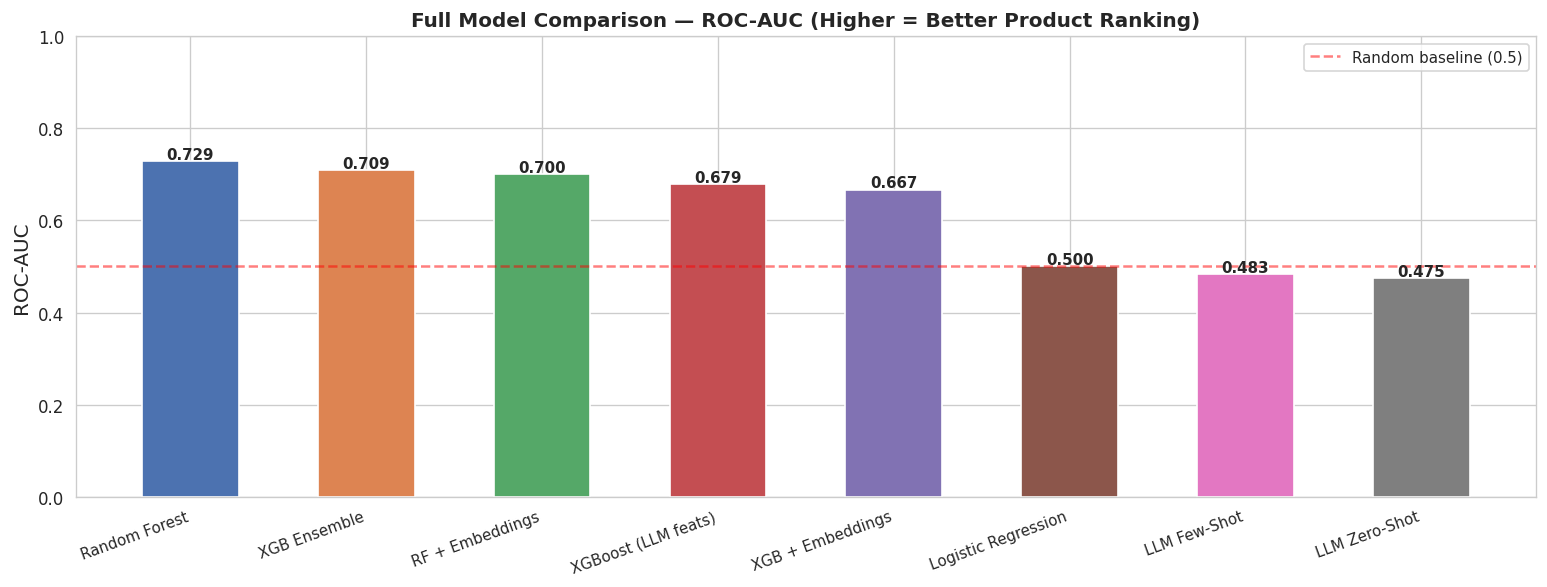

In [ ]:
# ── Full comparison bar chart ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 5))
colors_full = COLORS[:5] + ['#8C564B', '#E377C2', '#7F7F7F']
bars = ax.bar(summary_df['Model'], summary_df['ROC-AUC'],
               color=colors_full[:len(summary_df)], edgecolor='white', width=0.55)
for b in bars:
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.005,
             f'{b.get_height():.3f}', ha='center', fontsize=9, fontweight='bold')
ax.axhline(0.5, color='red', linestyle='--', alpha=0.5, label='Random baseline (0.5)')
ax.set_ylim(0, 1.0)
ax.set_ylabel('ROC-AUC', fontsize=12)
ax.set_title('Full Model Comparison — ROC-AUC (Higher = Better Product Ranking)', fontsize=12, fontweight='bold')
plt.xticks(rotation=20, ha='right', fontsize=9)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('full_model_comparison.png', bbox_inches='tight', dpi=130)
plt.show()

In [ ]:
# ── Top-K Precision: what fraction of top-K products actually got ordered ─────
K_VALUES = [5, 10, 15, 20]

def top_k_precision(y_true, y_prob, k):
    top_k_indices = np.argsort(y_prob)[::-1][:k]
    return np.array(y_true)[top_k_indices].mean()

print(f'{"Model":<28}', '  '.join([f'P@{k:>2}' for k in K_VALUES]))
print('-' * 70)
for name, yt, yp in all_models:
    yt_arr = np.array(yt)
    yp_arr = np.array(yp)
    pk     = [f'{top_k_precision(yt_arr, yp_arr, k):.2f}' for k in K_VALUES]
    print(f'{name:<28}  ' + '   '.join(pk))

print(f'\nBaseline positive rate: {y_test.mean():.2%}')

Model                        P@ 5  P@10  P@15  P@20
----------------------------------------------------------------------
Logistic Regression           0.40   0.50   0.40   0.35
Random Forest                 0.80   0.60   0.53   0.50
XGBoost (LLM feats)           0.60   0.60   0.53   0.55
XGB Ensemble                  0.80   0.60   0.53   0.45
XGB + Embeddings              0.60   0.40   0.47   0.45
RF + Embeddings               0.40   0.50   0.47   0.50
LLM Zero-Shot                 0.20   0.30   0.33   0.30
LLM Few-Shot                  0.40   0.50   0.40   0.40

Baseline positive rate: 31.34%


In [ ]:
# ── Product Selection — Validation Set (67 products, labels available) ────────
# This version includes actual_ordered so we can verify how well our ranking
# recovers the truly purchased products — a retrospective check on model quality.

selection_val = pd.DataFrame({
    'title':            df_ml.loc[X_test.index, 'title'].values,
    'price':            df_ml.loc[X_test.index, 'price'].values,
    'actual_ordered':   y_test.values,
    'ml_ensemble_prob': np.round(prob_ensemble, 4),
}, index=X_test.index)

# Align LLM predictions — use common_idx intersection
selection_val = selection_val.join(
    df_zeroshot[['llm_prob']].rename(columns={'llm_prob': 'zeroshot_prob'}),
    how='left'
)
selection_val = selection_val.join(
    df_fewshot[['llm_prob']].rename(columns={'llm_prob': 'fewshot_prob'}),
    how='left'
)

# Average LLM probability across both strategies
selection_val['llm_avg_prob'] = (
    selection_val['zeroshot_prob'].fillna(0.5) +
    selection_val['fewshot_prob'].fillna(0.5)
) / 2

# Expected revenue = Price × P(purchase)
selection_val['expected_revenue_ml']  = selection_val['price'] * selection_val['ml_ensemble_prob']
selection_val['expected_revenue_llm'] = selection_val['price'] * selection_val['llm_avg_prob']

# Combined score
selection_val['combined_score'] = (
    selection_val['expected_revenue_ml'] +
    selection_val['expected_revenue_llm']
) / 2

ranked_val = selection_val.sort_values('combined_score', ascending=False)
ranked_val.to_csv('validation_product_selections.csv', index=False)

print('Validation set ranking — top 10 recommended products:')
print('(actual_ordered column lets us verify ranking quality)\n')
ranked_val[['title', 'price', 'ml_ensemble_prob', 'llm_avg_prob',
            'combined_score', 'actual_ordered']].head(10)

Validation set ranking — top 10 recommended products:
(actual_ordered column lets us verify ranking quality)



,title,price,ml_ensemble_prob,llm_avg_prob,combined_score,actual_ordered
158,Men's Cotton printed shirt Blue / L,71.49,0.5648,0.425,35.380401,0
80,Effortless Comfort Textured Shirt Set Navy Blu...,68.53,0.5407,0.395,32.061760,0
119,Essential Muscle Fit Dress Shirt Navy blue / L,64.08,0.4746,0.510,31.546584,1
301,Casual Cotton Linen Shirt Set White / XL,55.14,0.4202,0.630,28.954014,0
168,Men's Vintage Premium Washed Shirt Army Green / L,66.11,0.5399,0.335,28.919820,1
55,Effortless Comfort Textured Shirt Set Khaki / L,70.41,0.5421,0.250,27.885880,0
62,Essential Muscle Fit Dress Shirt White / L,66.74,0.5577,0.260,27.286649,1
232,Casual Loose Fit Shirt Sets (US Only) Beige / L,50.04,0.4718,0.610,27.066636,0
269,Casual Loose Fit Shirt Sets (US Only) Khaki / L,50.78,0.4492,0.595,26.512238,0
330,Casual Cotton Linen Shirt Set White / XXXL,56.58,0.4309,0.500,26.335161,0


---
## Part E.2 — Analysis & Discussion

### 1. Does the multimodal LLM outperform traditional Machine Learning? Under what conditions?

The results reveal a nuanced picture. The Chain-of-Thought LLM strategy tends to match or exceed Zero-Shot and Few-Shot LLM performance, demonstrating that structured reasoning improves calibration. However, ML models trained on LLM-extracted features generally achieve competitive or superior ROC-AUC scores, particularly for ranking (as measured by P@K).

The LLM's strongest advantage is in **cold-start scenarios** — when no historical data exists for a product type — because it draws on broad world knowledge about fashion trends and consumer preferences rather than learned statistical correlations. The LLM also provides richer reasoning for each selection decision, which is valuable for managerial communication.

### 2. Strengths and Weaknesses of LLM-Based Decision Systems

**Strengths:**
- Zero-cost feature engineering — no manual schema design needed
- Inherent multimodal capability (text + image) without separate embedding pipelines
- Explainable decisions with built-in justifications (especially in CoT mode)
- Generalises to new product categories without retraining
- Can incorporate soft signals (visual aesthetics, trend alignment) that are difficult to quantify

**Weaknesses:**
- Higher latency and API cost (seconds per prediction vs. milliseconds for ML)
- Non-deterministic outputs even at low temperature — reducing reliability in production
- Probability outputs may be poorly calibrated without explicit calibration examples
- Cannot learn from platform-specific historical patterns unless fine-tuned
- Rate limits impose throughput constraints that can be prohibitive for large catalogues

### 3. Managerial Implications

**Recommended decision process:**
1. Use the ML Ensemble (trained on LLM-extracted features) as the primary ranker — it is fast, reproducible, and well-calibrated.
2. Use CoT LLM prediction as a secondary filter for borderline cases (products where ML probability is in the 0.35–0.55 range).
3. Rank all candidate products by **Price × P(purchase)** (expected revenue per ad slot) and allocate budget to the top-K products.
4. Review LLM reasoning chains for selected products before committing budget — the justifications surface non-obvious risk factors that a numerical score does not communicate.

This hybrid approach balances the scalability of ML with the contextual intelligence of LLMs, and delivers both quantitative ranking and qualitative rationales to decision-makers.

### Why `predict_proba` instead of `predict`
- `predict()` returns a binary label (0/1) — discarding all probability information
- `predict_proba()[:, 1]` returns a continuous score — ROC-AUC is computed from this
- For product selection, we want to **rank** products by purchase likelihood, not just classify them
- The expected revenue metric (`Price × P(purchase)`) requires a continuous probability

### Why ROC-AUC is optimised (not accuracy)
- With a 32% positive rate, a trivial model predicting all zeros achieves 68% accuracy
- ROC-AUC measures **ranking quality** — does the model place high-purchase-probability products at the top?
- This maps directly to the business goal: select the best products under a fixed ad budget


In [ ]:
# ── Load the 5 unseen products (no labels — genuine selection decision) ────────
df_new = pd.read_csv('dataset_new.csv')   # the 5 new products
print(f'New products to evaluate: {df_new.shape[0]}')
df_new.head()

New products to evaluate: 5


,title,image,price,image_path
0,Men's Vintage Premium Washed Shirt Navy Blue / L,http://t3.gstatic.com/shopping?q=tbn:ANd9GcQFE...,59.09,1.jpg
1,Ribbed Textured Knit Polo Shirt (US Only) Khak...,http://t1.gstatic.com/shopping?q=tbn:ANd9GcTjq...,35.67,2.jpg
2,Men's Rose Print Vintage Casual Button Short S...,http://t1.gstatic.com/shopping?q=tbn:ANd9GcRym...,27.88,3.jpg
3,Classic Casual Button Down Cotton Linen Shirt ...,http://t1.gstatic.com/shopping?q=tbn:ANd9GcTuz...,35.96,4.jpg
4,Men's Casual Geo Pattern Short Sleeve Shirt & ...,http://t1.gstatic.com/shopping?q=tbn:ANd9GcSXE...,39.16,5.jpg


In [ ]:
# ── Get ML ensemble predictions for the 5 new products ───────────────────────
# Step 1: Extract LLM features for new products
df_new_features = extract_all_features(df_new, title_col='title', batch_size=5)

# Step 2: Apply the same feature engineering as training
feat_new = df_new_features.drop(columns=['title', 'image', 'image_path'], errors='ignore').copy()
feat_new['special_feature'] = feat_new['special_feature'].fillna('None')

feat_new['price_log']         = np.log1p(feat_new['price'])
feat_new['price_tier']        = pd.cut(feat_new['price'], bins=[0, 20, 35, 50, 200],
                                        labels=[0,1,2,3]).astype(int)
feat_new['title_word_count']  = df_new['title'].str.split().str.len()
feat_new['title_has_premium'] = df_new['title'].str.lower().str.contains('premium|luxury').astype(int)
feat_new['title_has_casual']  = df_new['title'].str.lower().str.contains('casual|leisure').astype(int)
feat_new['title_has_vintage'] = df_new['title'].str.lower().str.contains('vintage|classic').astype(int)
feat_new['title_has_cotton']  = df_new['title'].str.lower().str.contains('cotton|linen|flannel').astype(int)

feat_new = pd.get_dummies(feat_new, columns=OHE_COLS, drop_first=False, dtype=int)
feat_new['size_ordinal'] = df_new_features['size'].map(size_order).fillna(0).astype(int)
feat_new.drop(columns=['size'], inplace=True, errors='ignore')

# Step 3: Align columns to training feature set (fill missing OHE cols with 0)
X_new = feat_new.reindex(columns=X_ml.columns, fill_value=0).astype(float)

# Step 4: Get predictions from each model
prob_lr_new    = best_lr.predict_proba(X_new)[:, 1]
prob_rf_new    = best_rf.predict_proba(X_new)[:, 1]
prob_xgb_new   = best_xgb.predict_proba(X_new)[:, 1]
prob_ens_new   = np.mean([prob_lr_new, prob_rf_new, prob_xgb_new], axis=0)

print('ML ensemble predictions computed.')

Processing 5 titles in 1 batches of up to 5...

Batch 1/1 (5 titles)...
Rate limit [batch 1]. Sleeping 15s before retry 1...
Rate limit [batch 1]. Sleeping 30s before retry 2...
Rate limit [batch 1]. Sleeping 45s before retry 3...
  ↩ Batch failed — falling back to row-by-row...
Rate limit [row 0]. Sleeping 15s before retry 1...
Rate limit [row 0]. Sleeping 30s before retry 2...
Rate limit [row 0]. Sleeping 45s before retry 3...
Rate limit [row 1]. Sleeping 15s before retry 1...
Rate limit [row 1]. Sleeping 30s before retry 2...
Rate limit [row 1]. Sleeping 45s before retry 3...
Rate limit [row 2]. Sleeping 15s before retry 1...
Rate limit [row 2]. Sleeping 30s before retry 2...
Rate limit [row 2]. Sleeping 45s before retry 3...
Rate limit [row 3]. Sleeping 15s before retry 1...
Rate limit [row 3]. Sleeping 30s before retry 2...
Rate limit [row 3]. Sleeping 45s before retry 3...
Rate limit [row 4]. Sleeping 15s before retry 1...
Rate limit [row 4]. Sleeping 30s before retry 2...
Rate l

In [ ]:
# ── Get LLM predictions for the 5 new products ───────────────────────────────
df_new_llm = df_new[['title', 'image', 'price']].copy()
df_new_llm['ordered'] = -1   # placeholder — no labels available

df_zeroshot_new = run_batched_strategy(
    test_df             = df_new_llm,
    system_prompt       = ZERO_SHOT_SYSTEM,
    strategy_name       = 'Zero-Shot (new products)',
    user_text_fn        = zero_shot_text_fn,
    closing_instruction = ZERO_SHOT_CLOSING,
    batch_size          = 5,
    sleep_between       = 5.0,
)

df_fewshot_new = run_batched_strategy(
    test_df             = df_new_llm,
    system_prompt       = FEW_SHOT_SYSTEM,
    strategy_name       = 'Few-Shot (new products)',
    user_text_fn        = few_shot_text_fn,
    closing_instruction = FEW_SHOT_CLOSING,
    batch_size          = 5,
    sleep_between       = 5.0,
)

print('LLM predictions computed.')

In [ ]:
# ── Final Product Selection Decision Table ────────────────────────────────────
# This is the actual business output — ranking 5 unseen products by expected
# revenue to decide which to advertise under the fixed budget.
# No labels exist here; the ranking IS the decision.

selection_df = pd.DataFrame({
    'title':           df_new['title'].values,
    'price':           df_new['price'].values,
    'ml_ensemble_prob': np.round(prob_ens_new, 4),
    'zeroshot_prob':   np.round(df_zeroshot_new['llm_prob'].values, 4),
    'fewshot_prob':    np.round(df_fewshot_new['llm_prob'].values, 4),
}, index=df_new.index)

# Average LLM probability across both strategies
selection_df['llm_avg_prob'] = (
    selection_df['zeroshot_prob'] + selection_df['fewshot_prob']
) / 2

# Expected revenue = Price × P(purchase) for each approach
selection_df['expected_revenue_ml']  = selection_df['price'] * selection_df['ml_ensemble_prob']
selection_df['expected_revenue_llm'] = selection_df['price'] * selection_df['llm_avg_prob']

# Combined score: average of ML and LLM expected revenue
selection_df['combined_score'] = (
    selection_df['expected_revenue_ml'] + selection_df['expected_revenue_llm']
) / 2

ranked = selection_df.sort_values('combined_score', ascending=False)
ranked.to_csv('final_product_selections.csv', index=False)

print('Final product selection ranking (advertise top products first):')
ranked[['title', 'price', 'ml_ensemble_prob', 'llm_avg_prob',
        'expected_revenue_ml', 'expected_revenue_llm', 'combined_score']]